# EDA — Dataset Enrichi : Connectivité ferroviaire intelligente
**Ligne Courpière–Ambert (785000) | UTBM – FEMTO-ST**

Progression en 7 sections :
1. Chargement & aperçu général
2. Qualité des données (valeurs manquantes, zones blanches)
3. Distribution des technologies et opérateurs
4. Performances réseau par génération
5. Impact de l'environnement (végétation, météo & LOS)
6. Score QoS et satisfaction applicative
7. Carte interactive de la ligne ferroviaire


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

PALETTE_GEN = {'2G': '#e74c3c', '3G': '#f39c12', '4G': '#3498db', '5G': '#2ecc71'}
PALETTE_OP  = {'ORANGE': '#FF7900', 'SFR': '#E2001A',
               'BOUYGUES TELECOM': '#009DE0', 'FREE MOBILE': '#CD1414'}
gen_order = ['2G', '3G', '4G', '5G']

print('Librairies chargées ✓')


Librairies chargées ✓


---
## 1. Chargement & aperçu général


In [5]:
import os

# Adaptez ce chemin si nécessaire
base_dir  = os.path.dirname(os.getcwd())
file_path = os.path.join(base_dir, 'data', 'processed', 'dataset_enrichi.csv')
if not os.path.exists(file_path):
    for cand in [
        os.path.join(os.getcwd(), 'dataset_enrichi.csv'),
        os.path.join(os.getcwd(), 'data', 'processed', 'dataset_enrichi.csv'),
    ]:
        if os.path.exists(cand):
            file_path = cand; break

df = pd.read_csv(file_path, low_memory=False)
print(f'  Fichier           : {file_path}')
print(f'  Dimensions        : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'  Points GPS        : {df["point_id"].nunique():,}')
print(f'  Antennes uniques  : {df["ant_id"].nunique()}')
# FIX : on affiche les scénarios réellement présents (pas "S1 à S4" en dur)
print(f'  Scénarios météo   : {sorted(df["scenario_id"].unique())}')
print(f'  Générations       : {sorted(df["generation"].unique())}')
print(f'  Opérateurs        : {sorted(df["operateur"].unique())}')
print(f'  Latitude          : {df["lat"].min():.4f} → {df["lat"].max():.4f}')
print(f'  Longitude         : {df["lon"].min():.4f} → {df["lon"].max():.4f}')
print('='*55)


  Fichier           : /home/meyssem/Documents/ferromobile_project/data/processed/dataset_enrichi.csv
  Dimensions        : 28,845 lignes × 73 colonnes
  Points GPS        : 1,923
  Antennes uniques  : 206
  Scénarios météo   : ['S3']
  Générations       : ['2G', '3G', '4G', '5G']
  Opérateurs        : ['BOUYGUES TELECOM', 'FREE MOBILE', 'ORANGE', 'SFR']
  Latitude          : 45.5424 → 45.7651
  Longitude         : 3.5279 → 3.7353


In [6]:
cols_apercu = ['point_id', 'distance_km', 'operateur', 'generation', 'bande_mhz',
               'dist_ant_km', 'snr_adjusted_db', 'debit_adj_mbps', 'rtt_ms',
               'score_qos_critique', 'zone_blanche', 'flag_etat_degrade', 'scenario_id']
df[cols_apercu].head(8)


,point_id,distance_km,operateur,generation,bande_mhz,dist_ant_km,snr_adjusted_db,debit_adj_mbps,rtt_ms,score_qos_critique,zone_blanche,flag_etat_degrade,scenario_id
0,0,0.0,BOUYGUES TELECOM,2G,900,1.7074,21.83,0.2400,334.1,0.6283,0,0,S3
1,0,0.0,SFR,2G,900,1.7074,21.83,0.2052,334.1,0.6075,0,0,S3
2,0,0.0,BOUYGUES TELECOM,3G,900,1.7074,27.84,7.2000,123.7,0.7220,0,0,S3
3,0,0.0,SFR,3G,900,1.7074,27.84,5.7077,123.7,0.6898,0,0,S3
4,0,0.0,SFR,4G,700,1.7074,31.96,37.3417,35.7,0.7744,0,0,S3
5,0,0.0,ORANGE,4G,700,1.7074,31.96,37.3418,35.7,0.7790,0,0,S3
6,0,0.0,SFR,4G,800,1.7074,31.96,37.8904,35.0,0.7811,0,0,S3
7,0,0.0,BOUYGUES TELECOM,4G,1800,1.7074,31.96,57.1955,42.2,0.7618,0,0,S3


In [7]:
cols_stats = ['dist_ant_km', 'debit_adj_mbps', 'snr_adjusted_db', 'rtt_ms',
              'ber', 'packet_loss_pct', 'score_qos', 'score_qos_critique',
              'cout_installation_eur', 'cout_mensuel_eur']
df[cols_stats].describe().round(2)


,dist_ant_km,debit_adj_mbps,snr_adjusted_db,rtt_ms,ber,packet_loss_pct,score_qos,score_qos_critique,cout_installation_eur,cout_mensuel_eur
count,28845.00,28845.00,28845.00,26280.00,28845.00,26280.00,28845.00,28845.00,28845.00,28845.00
mean,1.70,42.57,18.54,85.46,0.09,0.14,0.75,0.68,32591.44,325.91
std,0.98,58.36,36.91,90.39,0.28,2.91,0.24,0.22,18385.17,183.85
min,0.01,0.00,-99.00,15.10,0.00,0.04,0.00,0.00,10000.00,100.00
25%,0.89,5.60,27.84,34.20,0.00,0.04,0.78,0.70,20000.00,200.00
50%,1.58,35.76,31.96,40.40,0.00,0.04,0.85,0.77,30000.00,300.00
75%,2.31,44.03,31.96,122.20,0.00,0.04,0.86,0.79,35000.00,350.00
max,4.39,298.34,34.95,396.70,1.00,100.00,0.93,0.90,80000.00,800.00


---
## 2. Qualité des données — Valeurs manquantes & zones blanches

> **Rappel :** Les NaN sur `snr_db`, `rtt_ms` et `packet_loss_pct` sont **exclusivement**
> liés aux lignes en tunnel (`in_tunnel=True`). Ce ne sont pas des erreurs — en tunnel
> il n'y a aucun signal cellulaire actif.


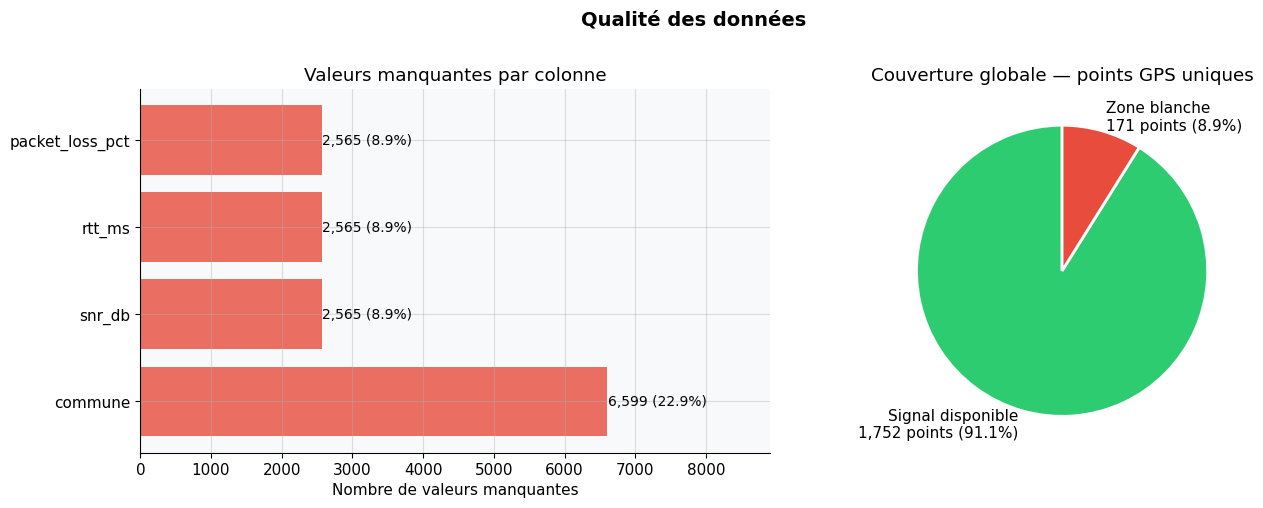


→ 171 points GPS / 1923 en zone blanche (8.9% du trajet)
→ Les NaN sur snr_db/rtt_ms/packet_loss_pct sont TOUS liés aux tunnels (in_tunnel=True)


In [8]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(nulls.index, nulls.values, color='#e74c3c', alpha=0.8)
for i, v in enumerate(nulls.values):
    axes[0].text(v + 10, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)
axes[0].set_xlabel('Nombre de valeurs manquantes')
axes[0].set_title('Valeurs manquantes par colonne')
axes[0].set_xlim(0, max(nulls.values) * 1.35)

# FIX : compter les POINTS GPS uniques en zone blanche, pas les lignes du dataset.
# Chaque point GPS a plusieurs lignes (une par antenne × génération candidate).
# df['zone_blanche'].sum() = 2 565 LIGNES (tunnel), pas 171 POINTS GPS.
# La bonne métrique pour un exposé : "X% du trajet sans couverture".
pts_zb    = df.groupby('point_id')['zone_blanche'].max()
nb_zb_pts = int(pts_zb.sum())
nb_ok_pts = int((pts_zb == 0).sum())
total_pts  = df['point_id'].nunique()

axes[1].pie(
    [nb_ok_pts, nb_zb_pts],
    labels=[
        f'Signal disponible\n{nb_ok_pts:,} points ({nb_ok_pts/total_pts*100:.1f}%)',
        f'Zone blanche\n{nb_zb_pts:,} points ({nb_zb_pts/total_pts*100:.1f}%)'
    ],
    colors=['#2ecc71', '#e74c3c'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Couverture globale — points GPS uniques')

plt.suptitle('Qualité des données', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_qualite_donnees.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n→ {nb_zb_pts} points GPS / {total_pts} en zone blanche ({nb_zb_pts/total_pts*100:.1f}% du trajet)')
print(f'→ Les NaN sur snr_db/rtt_ms/packet_loss_pct sont TOUS liés aux tunnels (in_tunnel=True)')


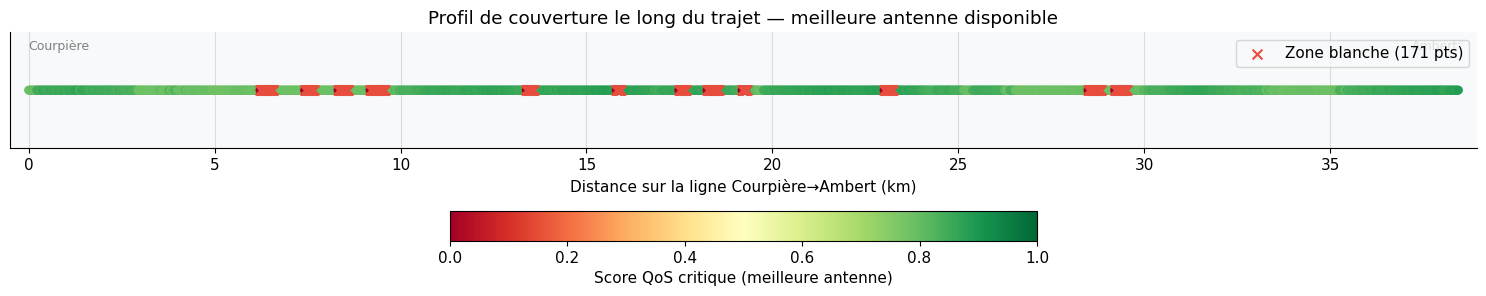

In [9]:
# FIX : idxmax() sur tous les scénarios confondus peut sélectionner une ligne
# EN TUNNEL (score_qos_critique=0) pour un point qui a du signal hors tunnel.
# On force la sélection sur les lignes HORS TUNNEL ; les points de tunnel restent
# affichés mais identifiés séparément (ils ont zone_blanche=1 par construction).
df_ht = df[~df['in_tunnel']]
best_per_point = df_ht.loc[df_ht.groupby('point_id')['score_qos_critique'].idxmax()].copy()

# Réintégrer les points uniquement en tunnel (pas de ligne hors tunnel)
pts_tunnel_only = set(df['point_id'].unique()) - set(df_ht['point_id'].unique())
if pts_tunnel_only:
    df_tun_rep = (df[df['point_id'].isin(pts_tunnel_only)]
                    .drop_duplicates('point_id')
                    .copy())
    best_per_point = pd.concat([best_per_point, df_tun_rep], ignore_index=True)

best_per_point = best_per_point.sort_values('distance_km')

fig, ax = plt.subplots(figsize=(15, 3))
sc = ax.scatter(best_per_point['distance_km'], [1]*len(best_per_point),
                c=best_per_point['score_qos_critique'].values,
                cmap='RdYlGn', s=30, vmin=0, vmax=1, zorder=3)
zb_pts_df = best_per_point[best_per_point['zone_blanche'] == 1]
ax.scatter(zb_pts_df['distance_km'], [1]*len(zb_pts_df),
           c='#e74c3c', s=50, zorder=4,
           label=f'Zone blanche ({len(zb_pts_df)} pts)', marker='x')
plt.colorbar(sc, ax=ax, label='Score QoS critique (meilleure antenne)',
             orientation='horizontal', shrink=0.4, pad=0.3)
ax.set_xlabel('Distance sur la ligne Courpière→Ambert (km)')
ax.set_yticks([])
ax.set_title('Profil de couverture le long du trajet — meilleure antenne disponible')
ax.set_xlim(-0.5, best_per_point['distance_km'].max() + 0.5)
ax.legend(loc='upper right')
ax.text(0, 0.85, 'Courpière', transform=ax.get_xaxis_transform(),
        ha='left', fontsize=9, color='gray')
ax.text(best_per_point['distance_km'].max(), 0.85, 'Ambert',
        transform=ax.get_xaxis_transform(), ha='right', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('fig2_profil_couverture.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Distribution des technologies & opérateurs


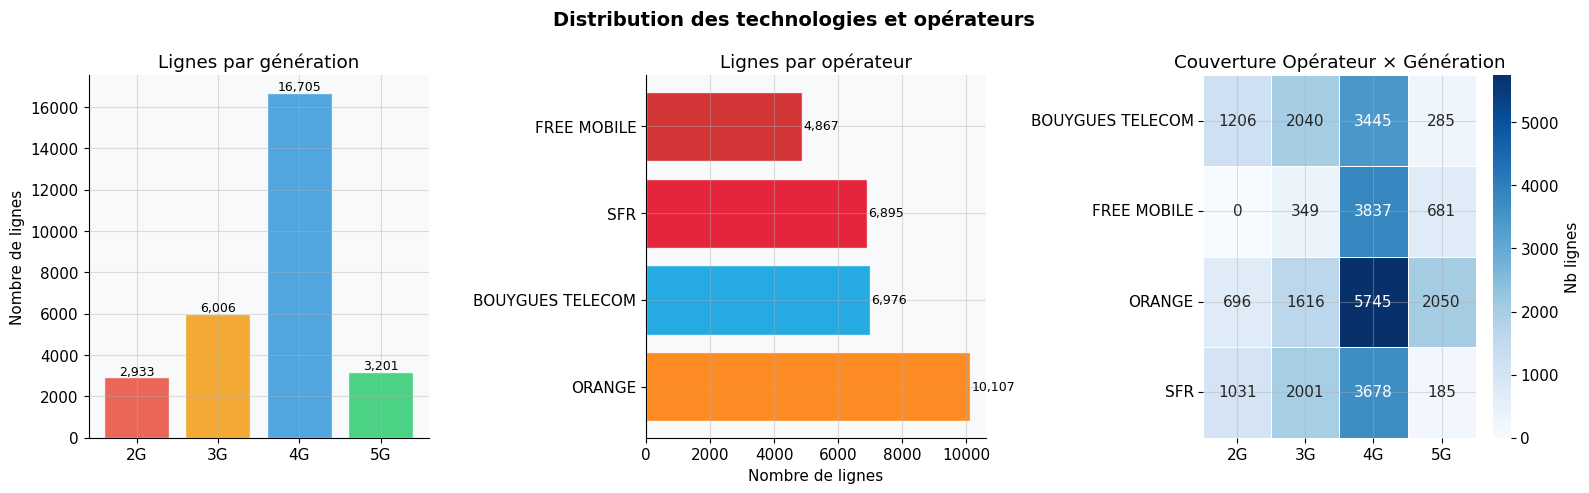

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gen_counts = df['generation'].value_counts().reindex(gen_order).dropna()
bars = axes[0].bar(gen_counts.index, gen_counts.values,
                   color=[PALETTE_GEN[g] for g in gen_counts.index],
                   alpha=0.85, edgecolor='white')
for bar, val in zip(bars, gen_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', fontsize=9)
axes[0].set_title('Lignes par génération')
axes[0].set_ylabel('Nombre de lignes')

op_counts = df['operateur'].value_counts()
bars2 = axes[1].barh(op_counts.index, op_counts.values,
                     color=[PALETTE_OP.get(o, '#95a5a6') for o in op_counts.index],
                     alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, op_counts.values):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_title('Lignes par opérateur')
axes[1].set_xlabel('Nombre de lignes')

pivot = df.pivot_table(index='operateur', columns='generation',
                       values='row_id', aggfunc='count', fill_value=0)
ordered_cols = [c for c in ['2G','3G','4G','5G'] if c in pivot.columns]
sns.heatmap(pivot[ordered_cols], annot=True, fmt='d', cmap='Blues', ax=axes[2],
            linewidths=0.5, cbar_kws={'label': 'Nb lignes'})
axes[2].set_title('Couverture Opérateur × Génération')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.suptitle('Distribution des technologies et opérateurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_distribution_tech_op.png', dpi=150, bbox_inches='tight')
plt.show()


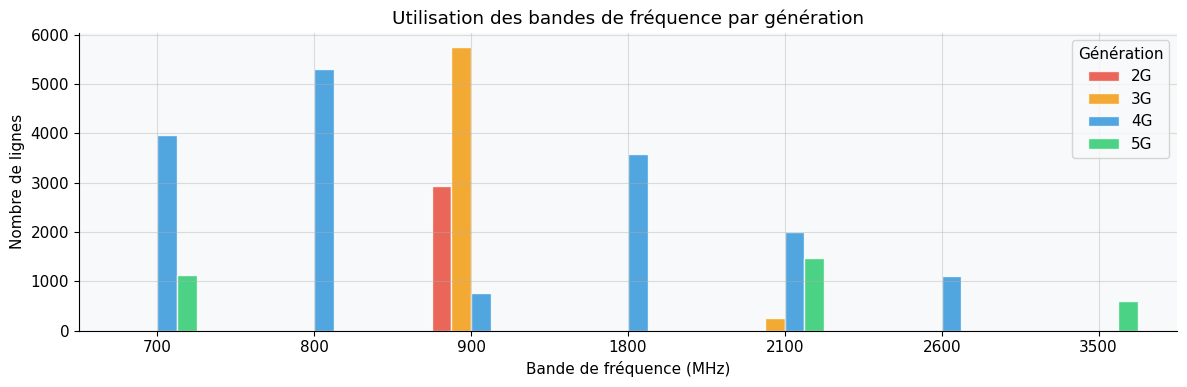


Débit moyen par génération et bande (Mb/s):
generation  bande_mhz
2G          900            0.2
3G          900            5.4
            2100           4.3
4G          700           33.3
            800           34.2
            900            6.6
            1800          52.4
            2100          37.8
            2600          48.6
5G          700          245.7
            2100         153.0
            3500          94.8


In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
bande_gen = df.groupby(['bande_mhz', 'generation'])['row_id'].count().reset_index()
bande_gen.columns = ['bande_mhz', 'generation', 'count']
pivot_bande = bande_gen.pivot(index='bande_mhz', columns='generation', values='count').fillna(0)
ordered = [c for c in ['2G','3G','4G','5G'] if c in pivot_bande.columns]
pivot_bande[ordered].plot(kind='bar', ax=ax,
                          color=[PALETTE_GEN[g] for g in ordered],
                          alpha=0.85, edgecolor='white')
ax.set_xlabel('Bande de fréquence (MHz)')
ax.set_ylabel('Nombre de lignes')
ax.set_title('Utilisation des bandes de fréquence par génération')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Génération')
plt.tight_layout()
plt.savefig('fig4_bandes_frequence.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDébit moyen par génération et bande (Mb/s):')
print(df.groupby(['generation','bande_mhz'])['debit_adj_mbps'].mean().round(1).to_string())


---
## 4. Performances réseau par génération

> **Objectif :** vérifier la cohérence physique des métriques.
> Débit 5G >> 4G >> 3G >> 2G, RTT 5G << 4G << 3G << 2G.


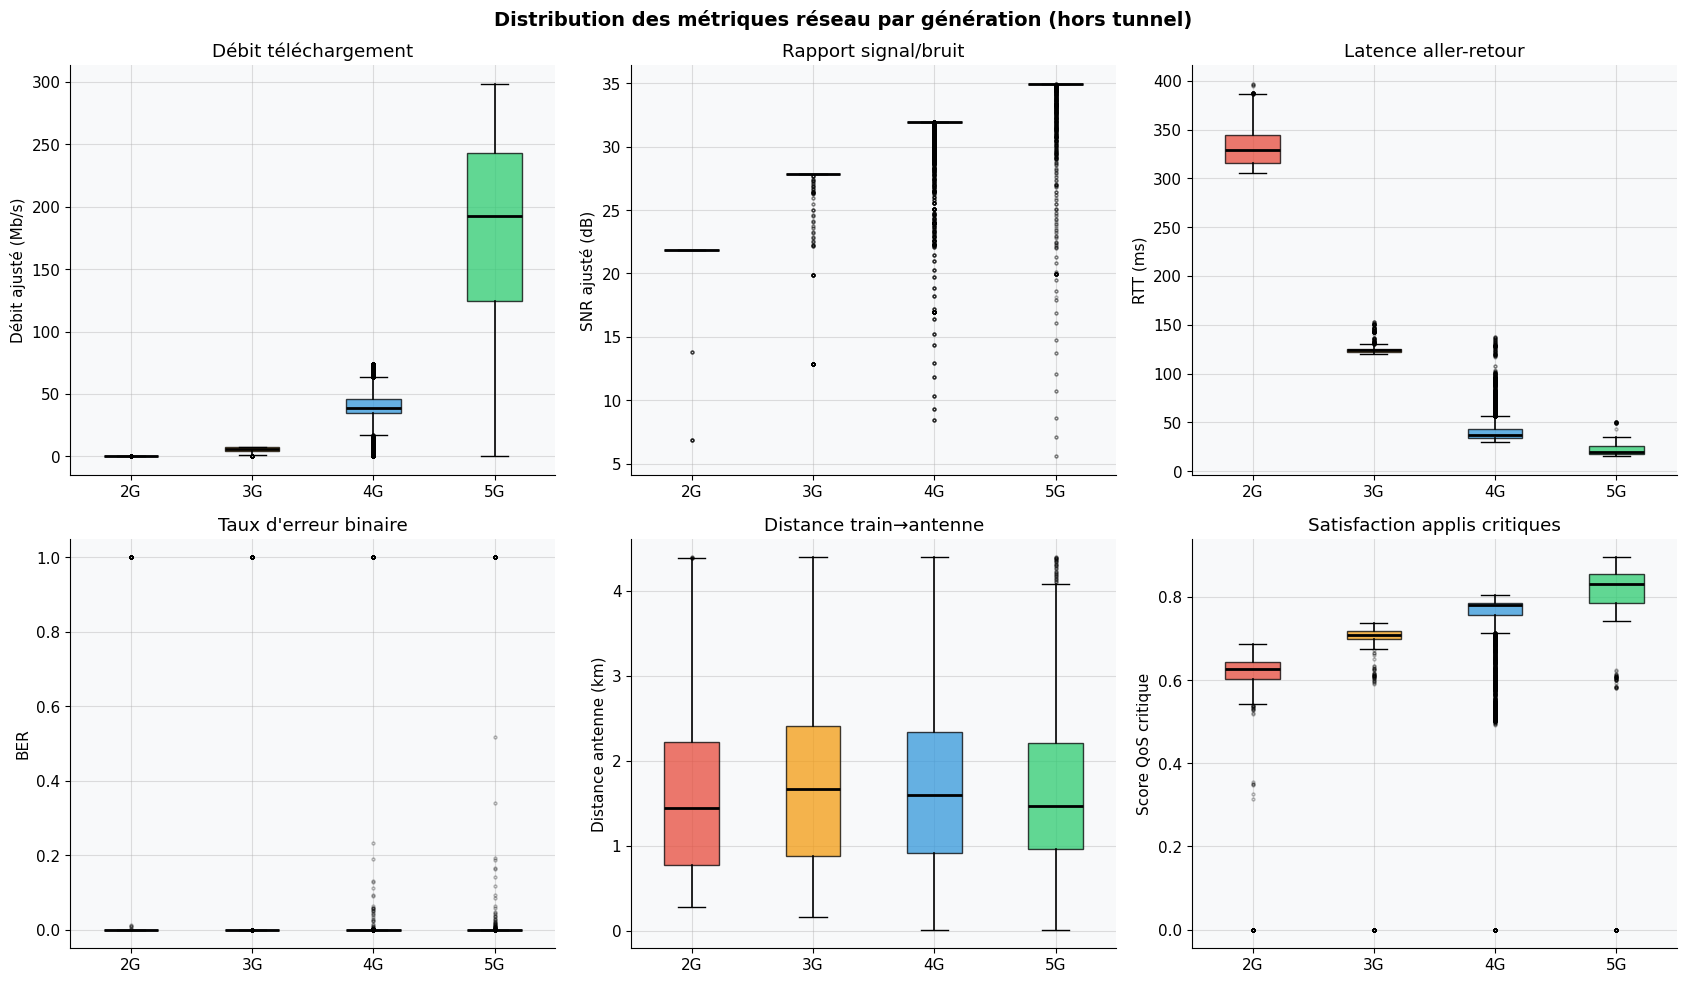

In [12]:
df_cell = df[df['tech_label'] == 'CELL'].copy()

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
metrics = [
    ('debit_adj_mbps',    'Débit ajusté (Mb/s)',     'Débit téléchargement'),
    ('snr_adjusted_db',   'SNR ajusté (dB)',          'Rapport signal/bruit'),
    ('rtt_ms',            'RTT (ms)',                 'Latence aller-retour'),
    ('ber',               'BER',                      "Taux d'erreur binaire"),
    ('dist_ant_km',       'Distance antenne (km)',    'Distance train→antenne'),
    ('score_qos_critique','Score QoS critique',       'Satisfaction applis critiques'),
]

for ax, (col, ylabel, title) in zip(axes.flat, metrics):
    # FIX : pour snr_adjusted_db, exclure les tunnels (sentinelle -99 ≠ NaN).
    # dropna() seul ne filtre pas -99, ce qui tire le boxplot vers le bas.
    if col == 'snr_adjusted_db':
        data = [df_cell[(df_cell['generation']==g) & (~df_cell['in_tunnel'])
                        & (df_cell[col] > -99)][col].dropna().values
                for g in gen_order]
    else:
        data = [df_cell[df_cell['generation']==g][col].dropna().values
                for g in gen_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops={'color':'black','linewidth':2},
                    whiskerprops={'linewidth':1.2},
                    flierprops={'marker':'o','markersize':2,'alpha':0.3})
    for patch, gen in zip(bp['boxes'], gen_order):
        patch.set_facecolor(PALETTE_GEN[gen])
        patch.set_alpha(0.75)
    ax.set_xticklabels(gen_order)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.suptitle('Distribution des métriques réseau par génération (hors tunnel)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_metriques_par_gen.png', dpi=150, bbox_inches='tight')
plt.show()


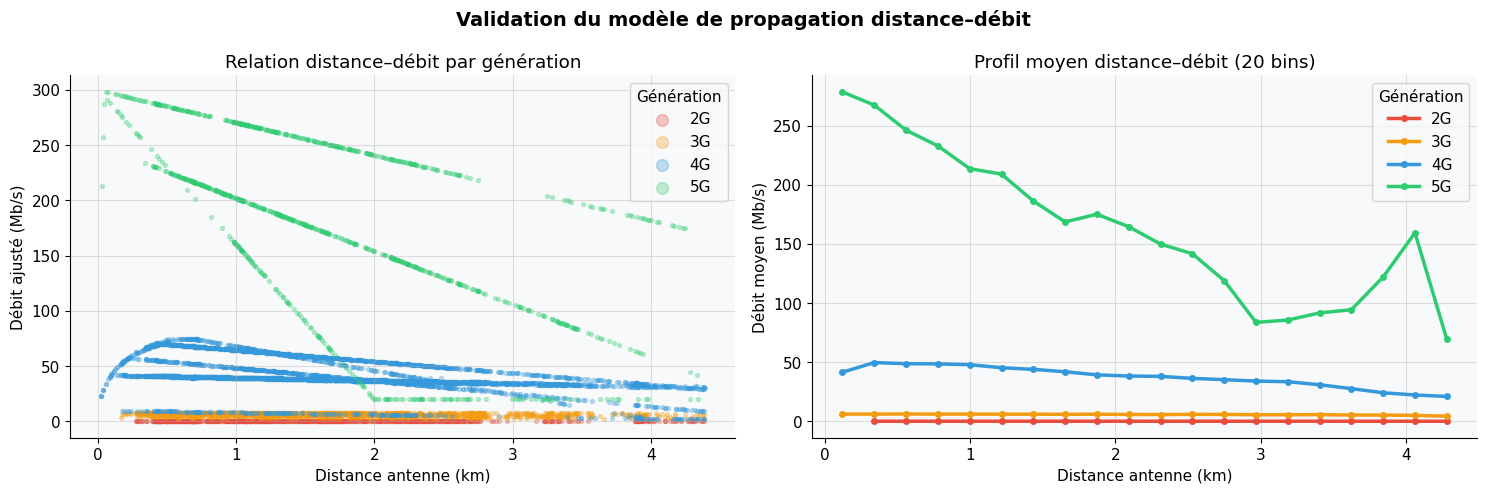

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# FIX : exclure les tunnels du scatter et des bins pour ne pas polluer
# la relation distance–débit avec des points à débit=0 (absence de signal)
df_cell_ht = df_cell[~df_cell['in_tunnel']].copy()
sample = df_cell_ht.sample(min(8000, len(df_cell_ht)), random_state=42)

for gen in gen_order:
    sub = sample[sample['generation'] == gen]
    axes[0].scatter(sub['dist_ant_km'], sub['debit_adj_mbps'],
                    c=PALETTE_GEN[gen], alpha=0.3, s=8, label=gen)
axes[0].set_xlabel('Distance antenne (km)')
axes[0].set_ylabel('Débit ajusté (Mb/s)')
axes[0].set_title('Relation distance–débit par génération')
axes[0].legend(title='Génération', markerscale=3)

df_cell_ht['dist_bin'] = pd.cut(df_cell_ht['dist_ant_km'], bins=20)
for gen in gen_order:
    sub = df_cell_ht[df_cell_ht['generation'] == gen]
    mean_debit = sub.groupby('dist_bin', observed=True)['debit_adj_mbps'].mean()
    midpoints  = [interval.mid for interval in mean_debit.index]
    axes[1].plot(midpoints, mean_debit.values, color=PALETTE_GEN[gen],
                 linewidth=2.5, label=gen, marker='o', markersize=4)
axes[1].set_xlabel('Distance antenne (km)')
axes[1].set_ylabel('Débit moyen (Mb/s)')
axes[1].set_title('Profil moyen distance–débit (20 bins)')
axes[1].legend(title='Génération')

plt.suptitle('Validation du modèle de propagation distance–débit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_profil_distance_debit.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Impact de l'environnement — Végétation, météo & LOS


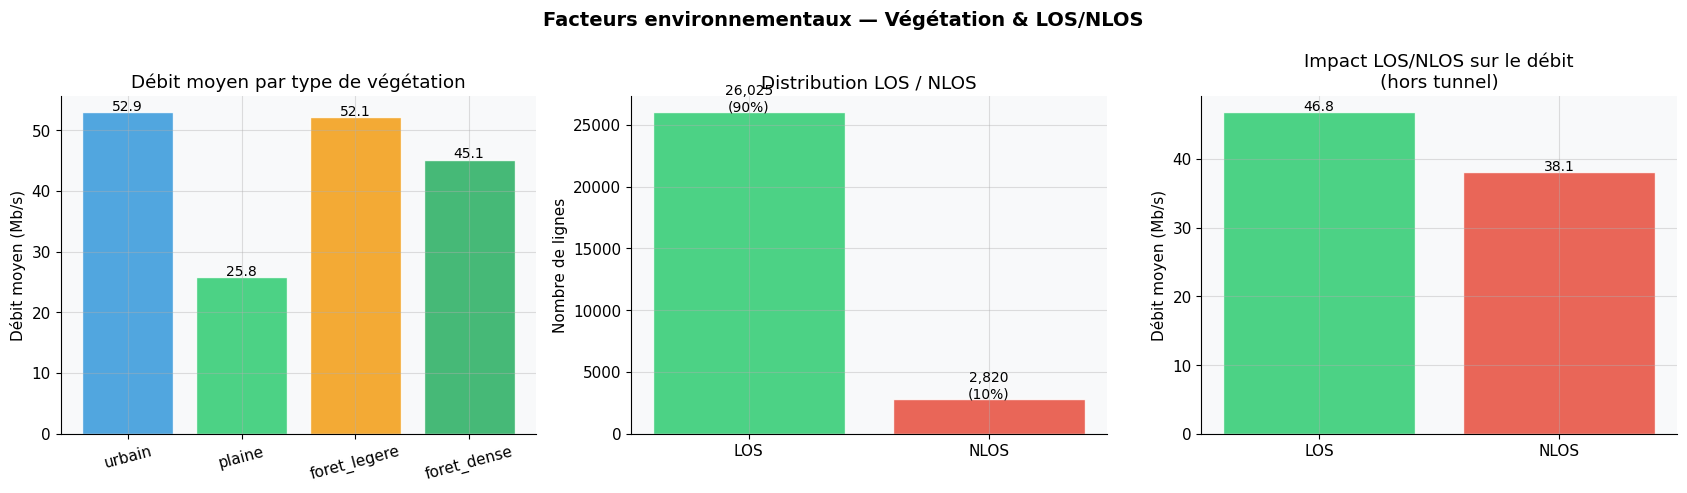

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Débit par végétation (hors tunnel)
df_cell_ht = df_cell[~df_cell['in_tunnel']]
veg_order  = ['urbain', 'plaine', 'foret_legere', 'foret_dense']
veg_colors = ['#3498db', '#2ecc71', '#f39c12', '#27ae60']
veg_means  = df_cell_ht.groupby('vegetation')['debit_adj_mbps'].mean().reindex(veg_order)
axes[0].bar(veg_order, veg_means.values, color=veg_colors, alpha=0.85, edgecolor='white')
for i, v in enumerate(veg_means.values):
    if not np.isnan(v):
        axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)
axes[0].set_ylabel('Débit moyen (Mb/s)')
axes[0].set_title('Débit moyen par type de végétation')
axes[0].tick_params(axis='x', rotation=15)

# LOS/NLOS binaire : 3=LOS, tout le reste (0,1,2) = NLOS
# tunnels (0) + bloqué (1) + Fresnel partiel (2) → tous NLOS
df['los_binary'] = df['los_category'].map(
    lambda x: 'LOS' if x == 3 else 'NLOS'
)

los_counts = df['los_binary'].value_counts().reindex(['LOS', 'NLOS'])
bars_los = axes[1].bar(
    los_counts.index, los_counts.values,
    color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white'
)
for bar, v in zip(bars_los, los_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{v:,}\n({v/len(df)*100:.0f}%)',
        ha='center', fontsize=10
    )
axes[1].set_ylabel('Nombre de lignes')
axes[1].set_title('Distribution LOS / NLOS')

# Débit moyen LOS vs NLOS hors tunnel
df_cell_ht2 = df_cell[~df_cell['in_tunnel']].copy()
df_cell_ht2['los_binary2'] = df_cell_ht2['los_category'].map(
    lambda x: 'LOS' if x == 3 else 'NLOS'
)
los_debit = (df_cell_ht2.groupby('los_binary2')['debit_adj_mbps']
             .mean()
             .reindex(['LOS', 'NLOS']))
bars2 = axes[2].bar(
    los_debit.index, los_debit.values,
    color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white'
)
for bar, v in zip(bars2, los_debit.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, v + 0.2,
                 f'{v:.1f}', ha='center', fontsize=10)
axes[2].set_ylabel('Débit moyen (Mb/s)')
axes[2].set_title('Impact LOS/NLOS sur le débit\n(hors tunnel)')

plt.suptitle('Facteurs environnementaux — Végétation & LOS/NLOS',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_environnement.png', dpi=150, bbox_inches='tight')
plt.show()

Scénarios présents dans ce dataset : ['S3']


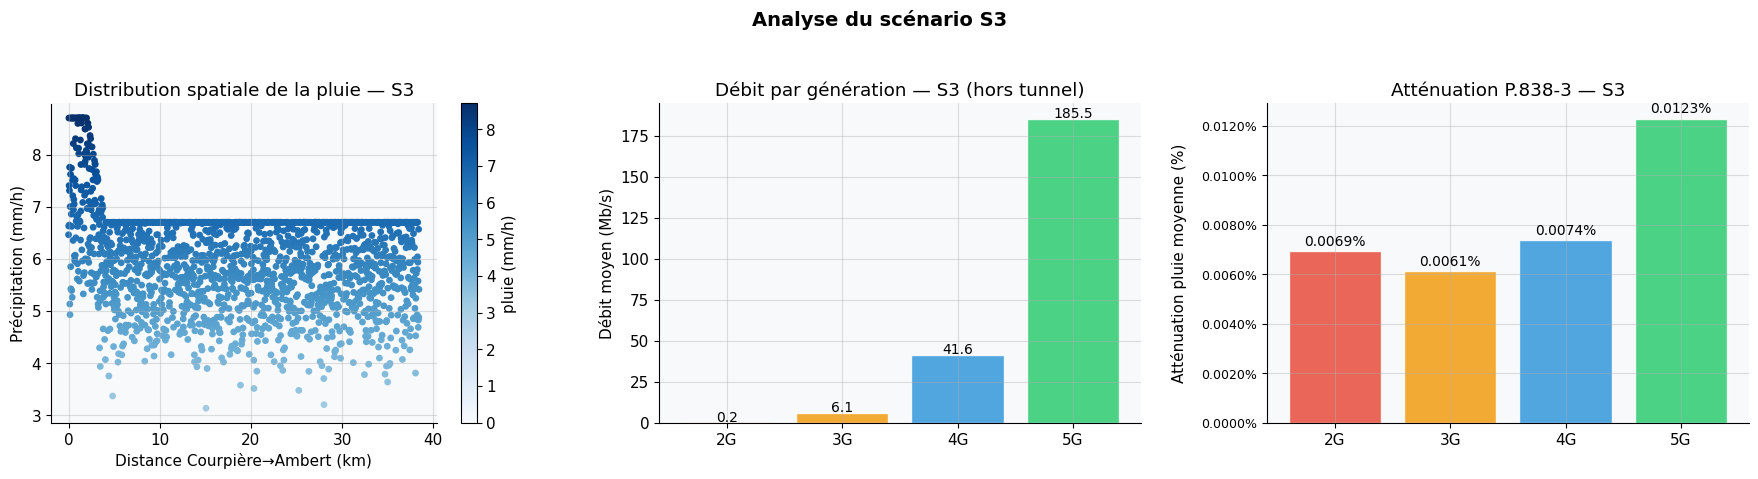

In [15]:
scenarios_presents = sorted(df['scenario_id'].unique())
print(f'Scénarios présents dans ce dataset : {scenarios_presents}')

scenario_ref = scenarios_presents[0]
df_sc    = df[df['scenario_id'] == scenario_ref]
df_sc_ht = df_sc[~df_sc['in_tunnel']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panneau 1 : pluie spatiale
pts_sc = df_sc.drop_duplicates('point_id').sort_values('distance_km')
sc_map = axes[0].scatter(pts_sc['distance_km'], pts_sc['pluie_mm_h'],
                         c=pts_sc['pluie_mm_h'], cmap='Blues', s=15, vmin=0)
plt.colorbar(sc_map, ax=axes[0], label='pluie (mm/h)')
axes[0].set_xlabel('Distance Courpière→Ambert (km)')
axes[0].set_ylabel('Précipitation (mm/h)')
axes[0].set_title(f'Distribution spatiale de la pluie — {scenario_ref}')

# Panneau 2 : débit par génération
debit_gen = (df_sc_ht.groupby('generation')['debit_adj_mbps']
             .mean().reindex(gen_order).dropna())
bars = axes[1].bar(debit_gen.index, debit_gen.values,
                   color=[PALETTE_GEN[g] for g in debit_gen.index],
                   alpha=0.85, edgecolor='white')
for bar, val in zip(bars, debit_gen.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontsize=10)
axes[1].set_ylabel('Débit moyen (Mb/s)')
axes[1].set_title(f'Débit par génération — {scenario_ref} (hors tunnel)')

# Panneau 3 : atténuation P.838-3
# FIX ylabel coupé : pad augmenté + labelpad explicite
# FIX axe y : valeurs en % lisibles (pas 0.00001), formatées directement
atten_gen = (df_sc_ht.groupby('generation')['attenuation_pluie_pct']
             .mean().reindex(gen_order).dropna())
bars2 = axes[2].bar(atten_gen.index, atten_gen.values,
                    color=[PALETTE_GEN[g] for g in atten_gen.index],
                    alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, atten_gen.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + atten_gen.max() * 0.02,
                 f'{val:.4f}%', ha='center', fontsize=10)
axes[2].set_ylabel('Atténuation pluie moyenne (%)', labelpad=10)
axes[2].set_title(f'Atténuation P.838-3 — {scenario_ref}')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.4f}%')
)
axes[2].tick_params(axis='y', labelsize=9)

plt.suptitle(f'Analyse du scénario {scenario_ref}', fontsize=14, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.savefig('fig8_scenario_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Score QoS and satisfaction applicative


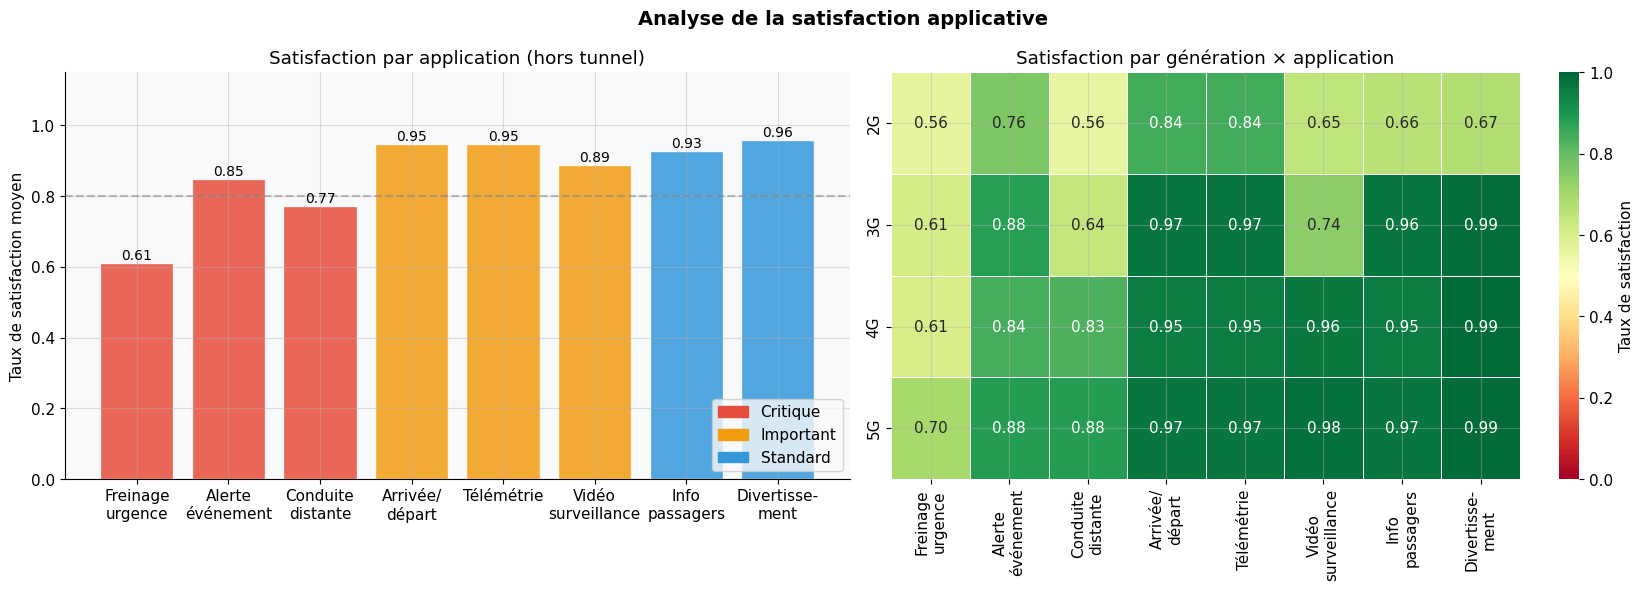

In [16]:
apps = ['sat_freinage_urgence', 'sat_alerte_evenement', 'sat_conduite_distante',
        'sat_arrivee_depart', 'sat_telemetrie', 'sat_video_surveillance',
        'sat_info_passagers', 'sat_divertissement']
apps_labels = ['Freinage\nurgence', 'Alerte\névénement', 'Conduite\ndistante',
               'Arrivée/\ndépart', 'Télémétrie', 'Vidéo\nsurveillance',
               'Info\npassagers', 'Divertisse-\nment']
app_colors = ['#e74c3c','#e74c3c','#e74c3c','#f39c12','#f39c12','#f39c12','#3498db','#3498db']

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# FIX : utiliser les lignes HORS TUNNEL pour les scores de satisfaction.
# En tunnel, tous les sat_* = 0 par construction (rtt=NaN → score=0).
# Les inclure ferait baisser artificiellement les moyennes.
df_cell_ht = df_cell[~df_cell['in_tunnel']]
sat_means  = df_cell_ht[apps].mean()

bars = axes[0].bar(apps_labels, sat_means.values, color=app_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, sat_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.2f}', ha='center', fontsize=10)
axes[0].axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Seuil 80%')
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Taux de satisfaction moyen')
axes[0].set_title('Satisfaction par application (hors tunnel)')
patches = [mpatches.Patch(color='#e74c3c', label='Critique'),
           mpatches.Patch(color='#f39c12', label='Important'),
           mpatches.Patch(color='#3498db', label='Standard')]
axes[0].legend(handles=patches, loc='lower right')

sat_by_gen = df_cell_ht.groupby('generation')[apps].mean().reindex(gen_order)
sat_by_gen.columns = apps_labels
sns.heatmap(sat_by_gen, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1], vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Taux de satisfaction'})
axes[1].set_title('Satisfaction par génération × application')
axes[1].set_ylabel('')

plt.suptitle('Analyse de la satisfaction applicative', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_satisfaction_apps.png', dpi=150, bbox_inches='tight')
plt.show()


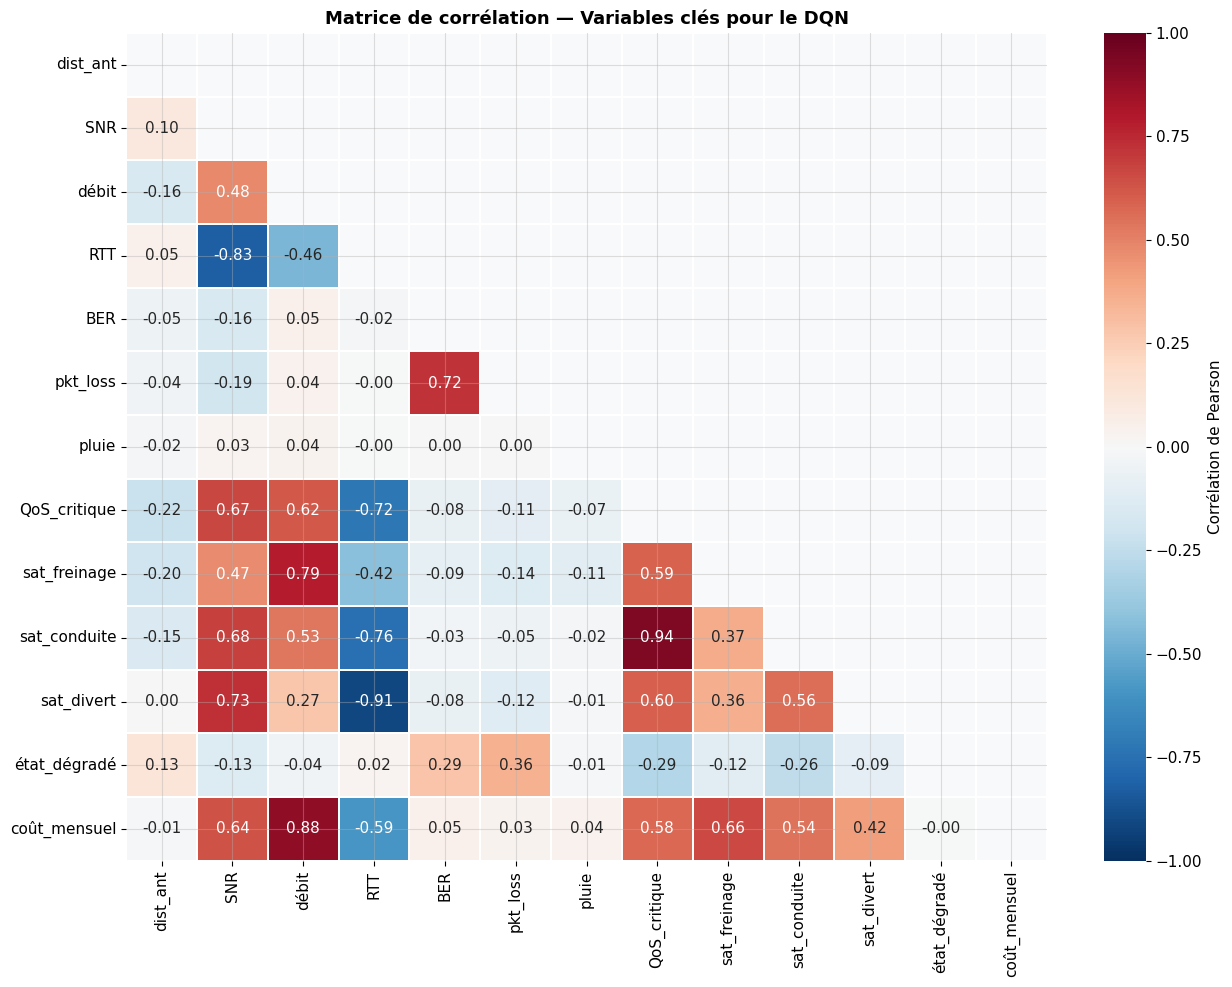


→ Corrélations fortes avec score_qos_critique :
sat_conduite    0.936
RTT             0.720
SNR             0.668
débit           0.618
sat_divert      0.596
sat_freinage    0.589


In [17]:
cols_corr = ['dist_ant_km', 'snr_adjusted_db', 'debit_adj_mbps', 'rtt_ms', 'ber',
             'packet_loss_pct', 'pluie_mm_h', 'score_qos_critique',
             'sat_freinage_urgence', 'sat_conduite_distante', 'sat_divertissement',
             'flag_etat_degrade', 'cout_mensuel_eur']
labels_corr = ['dist_ant', 'SNR', 'débit', 'RTT', 'BER',
               'pkt_loss', 'pluie', 'QoS_critique',
               'sat_freinage', 'sat_conduite', 'sat_divert',
               'état_dégradé', 'coût_mensuel']

# FIX : exclure les tunnels AVANT dropna.
# rtt_ms et packet_loss_pct sont NaN en tunnel → dropna les retire de toute façon,
# MAIS snr_adjusted_db=-99 en tunnel n'est PAS NaN → il survivrait à dropna et
# biaiserait la corrélation SNR. On filtre explicitement pour être sûr.
df_corr = df_cell[~df_cell['in_tunnel']][cols_corr].dropna()
corr = df_corr.corr()
corr.columns = labels_corr
corr.index   = labels_corr

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            ax=ax, vmin=-1, vmax=1, center=0,
            linewidths=0.3, cbar_kws={'label': 'Corrélation de Pearson'})
ax.set_title('Matrice de corrélation — Variables clés pour le DQN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Corrélations fortes avec score_qos_critique :')
corr_qos = corr['QoS_critique'].drop('QoS_critique').abs().sort_values(ascending=False)
print(corr_qos.head(6).round(3).to_string())


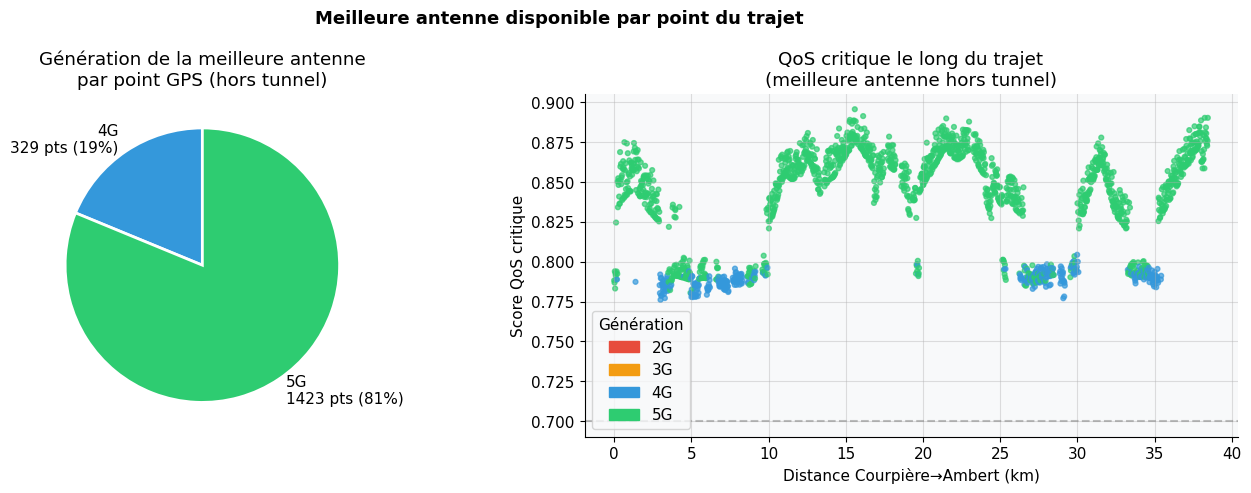

In [18]:
# FIX : idem section 2 — groupby idxmax sur hors-tunnel uniquement
df_ht   = df_cell[~df_cell['in_tunnel']]
best_ht = df_ht.loc[df_ht.groupby('point_id')['score_qos_critique'].idxmax()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_gen_counts = best_ht['generation'].value_counts().reindex(gen_order).dropna()
axes[0].pie(best_gen_counts.values,
            labels=[f'{g}\n{int(v)} pts ({v/len(best_ht)*100:.0f}%)'
                    for g, v in best_gen_counts.items()],
            colors=[PALETTE_GEN[g] for g in best_gen_counts.index],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Génération de la meilleure antenne\npar point GPS (hors tunnel)')

axes[1].scatter(best_ht['distance_km'], best_ht['score_qos_critique'],
                c=[PALETTE_GEN[g] for g in best_ht['generation']],
                s=12, alpha=0.7)
axes[1].axhline(0.7, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.7')
axes[1].set_xlabel('Distance Courpière→Ambert (km)')
axes[1].set_ylabel('Score QoS critique')
axes[1].set_title('QoS critique le long du trajet\n(meilleure antenne hors tunnel)')
legend_patches = [mpatches.Patch(color=PALETTE_GEN[g], label=g) for g in gen_order]
axes[1].legend(handles=legend_patches, title='Génération')

plt.suptitle('Meilleure antenne disponible par point du trajet', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_meilleure_antenne.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Carte interactive — Ligne ferroviaire & couverture réseau


In [19]:
try:
    import folium
    from folium.plugins import MarkerCluster
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print('folium non installé — pip install folium')

if HAS_FOLIUM:
    # FIX : se restreindre à un seul scénario pour éviter les doublons
    # géométriques (même point_id plusieurs fois si S1-S4 concaténés dans df)
    scenario_ref = df['scenario_id'].iloc[0]
    df_ref = df[df['scenario_id'] == scenario_ref].copy()
    print(f'  Carte construite sur le scénario : {scenario_ref}')

    trajet = df_ref.drop_duplicates('point_id').sort_values('distance_km')
    trajet_coords = list(zip(trajet['lat'], trajet['lon']))

    m = folium.Map(location=[trajet['lat'].mean(), trajet['lon'].mean()],
                   zoom_start=11, tiles='CartoDB positron')

    folium.PolyLine(trajet_coords, color='#2c3e50', weight=3,
                    opacity=0.8, tooltip='Ligne 785000').add_to(m)

    zb = trajet[trajet['zone_blanche'] == 1]
    for _, row in zb.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=8, color='#e74c3c', fill=True, fill_color='#e74c3c',
            fill_opacity=0.8,
            tooltip=f'Zone blanche — km {row["distance_km"]:.1f}'
        ).add_to(m)

    ant_df = df_ref.drop_duplicates('ant_id')[
        ['ant_id','ant_lat','ant_lon','generation','operateur','bande_mhz']]
    color_map_folium = {'2G':'red','3G':'orange','4G':'blue','5G':'green'}
    cluster = MarkerCluster(name='Antennes', disableClusteringAtZoom=12).add_to(m)
    for _, row in ant_df.iterrows():
        folium.CircleMarker(
            location=[row['ant_lat'], row['ant_lon']], radius=6,
            color=color_map_folium.get(row['generation'], 'gray'),
            fill=True, fill_opacity=0.9,
            tooltip=f"{row['operateur']} | {row['generation']} | {row['bande_mhz']} MHz"
        ).add_to(cluster)

    legend_html = '''
    <div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
                padding:12px;border-radius:8px;border:1px solid #ccc;font-size:13px">
        <b>Légende</b><br>
        <span style="color:#2c3e50">━━</span> Ligne 785000<br>
        <span style="color:#e74c3c">●</span> Zone blanche<br>
        <span style="color:red">●</span> 2G &nbsp;
        <span style="color:orange">●</span> 3G &nbsp;
        <span style="color:blue">●</span> 4G &nbsp;
        <span style="color:green">●</span> 5G
    </div>'''
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl().add_to(m)
    m.save('carte_ligne_ferroviaire.html')
    print(f'Carte sauvegardée : carte_ligne_ferroviaire.html')
    print(f'  → {len(trajet_coords)} points | {len(zb)} zones blanches | {len(ant_df)} antennes')
    display(m)


  Carte construite sur le scénario : S3
Carte sauvegardée : carte_ligne_ferroviaire.html
  → 1923 points | 171 zones blanches | 206 antennes


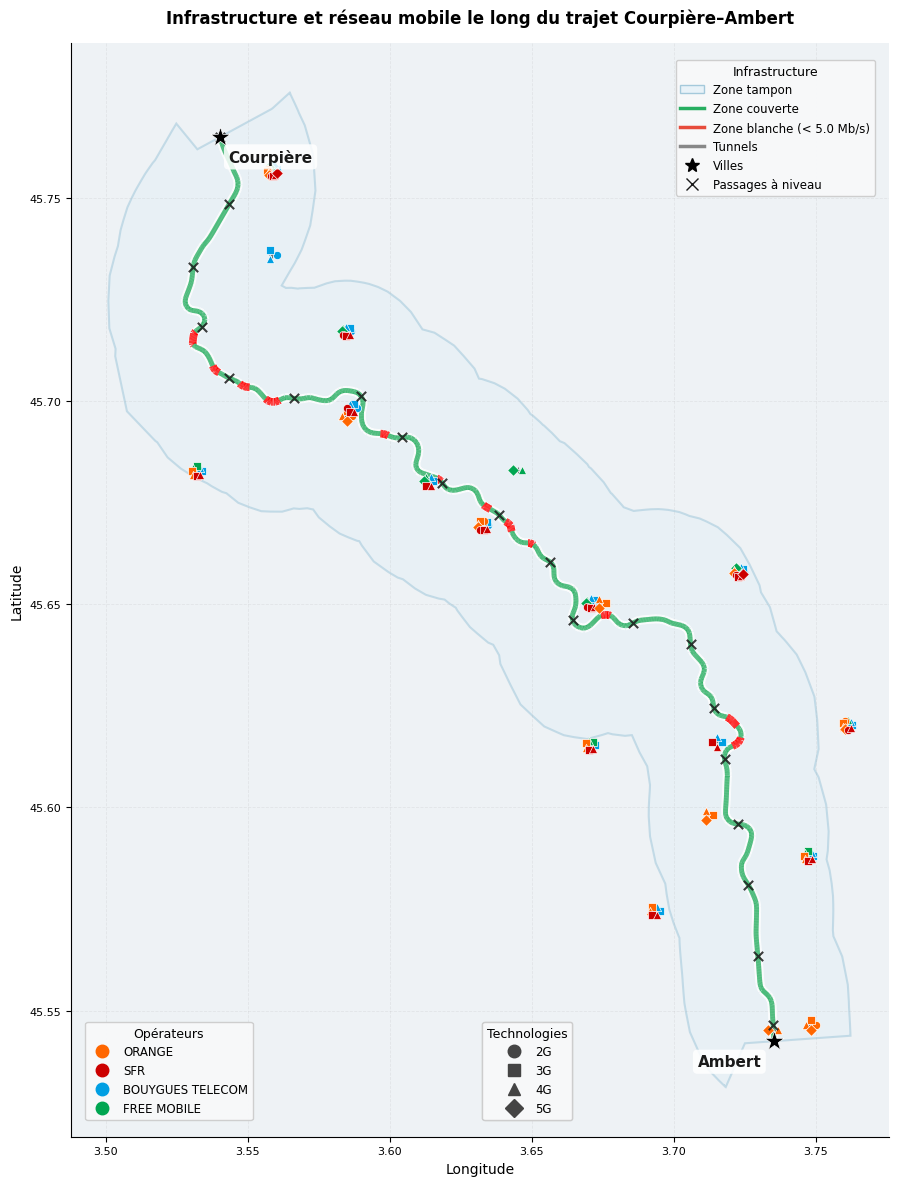

Carte générée — 125 marqueurs antennes (206 bruts → 125 dédupliqués)


In [31]:
from shapely.geometry import LineString
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

SEUIL_DEBIT_MBPS = 5.0

# ── 1. Voie ferrée ────────────────────────────────────────────────────────────
voie = df.groupby('point_id').agg(
    lat         = ('lat',            'first'),
    lon         = ('lon',            'first'),
    distance_km = ('distance_km',    'first'),
    in_tunnel   = ('in_tunnel',      'first'),
    best_debit  = ('debit_adj_mbps', 'max'),
).reset_index().sort_values('distance_km')

voie['zone_blanche_carte'] = np.where(
    voie['in_tunnel'], 2,
    np.where(voie['best_debit'] < SEUIL_DEBIT_MBPS, 1, 0)
)

# ── 2. Antennes ───────────────────────────────────────────────────────────────
ant_raw = df.groupby('ant_id').agg(
    ant_lat   = ('ant_lat',    'first'),
    ant_lon   = ('ant_lon',    'first'),
    operateur = ('operateur',  'first'),
    generation= ('generation', 'first'),
).reset_index().dropna(subset=['ant_lat','ant_lon'])

ant_raw['pos_key'] = (ant_raw['ant_lat'].round(3).astype(str) + '_' +
                      ant_raw['ant_lon'].round(3).astype(str))

antennes = (ant_raw
    .groupby(['pos_key','operateur','generation'], as_index=False)
    .agg(ant_lat=('ant_lat','first'), ant_lon=('ant_lon','first')))

# ── 3. Palettes ───────────────────────────────────────────────────────────────
COLORS_OP = {
    'ORANGE':           '#FF6600',
    'SFR':              '#CC0000',
    'BOUYGUES TELECOM': '#009FE3',
    'FREE MOBILE':      '#00A651',
}
MARKERS_GEN = {'2G': 'o', '3G': 's', '4G': '^', '5G': 'D'}
COLOR_VOIE  = {0: '#27ae60', 1: '#e74c3c', 2: '#888888'}

# ── 4. Zone tampon ────────────────────────────────────────────────────────────
RAYON_TAMPON_KM = 3.0
buffer_deg  = RAYON_TAMPON_KM / 111
ligne_geom  = LineString(list(zip(voie['lon'], voie['lat'])))
zone_tampon = ligne_geom.buffer(
    buffer_deg, cap_style=2, join_style=2, mitre_limit=5.0, resolution=8
)

# ── 5. Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor('#eef2f5')
fig.patch.set_facecolor('white')
lat_mean = voie['lat'].mean()
ax.set_aspect(1.0 / np.cos(np.radians(lat_mean)))

# ── 6. Zone tampon (dessin) ───────────────────────────────────────────────────
polys = zone_tampon.geoms if zone_tampon.geom_type == 'MultiPolygon' else [zone_tampon]
for poly in polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, facecolor='#daeef8', edgecolor='#5a9fc0',
            lw=1.5, alpha=0.28, zorder=1)
# ── 7. Voie ferrée — double passe (tunnels en rouge) ──────────────────────────

COLOR_VOIE  = {
    0: '#27ae60',  # couverture normale
    1: '#e74c3c',  # zone blanche
    2: '#ff0000'   # tunnels (rouge)
}

for i in range(len(voie) - 1):
    r, r2 = voie.iloc[i], voie.iloc[i + 1]

    color = COLOR_VOIE[r['zone_blanche_carte']]

    lw = 5.5 if r['zone_blanche_carte'] == 2 else 3.5

    # fond blanc (effet rail)
    ax.plot([r['lon'], r2['lon']], [r['lat'], r2['lat']],
            color='white', lw=6.5, zorder=2,
            solid_capstyle='butt')

    # ligne principale
    ax.plot([r['lon'], r2['lon']], [r['lat'], r2['lat']],
            color=color, lw=lw, zorder=3,
            solid_capstyle='butt',
            solid_joinstyle='miter')
# ── 8. Antennes ───────────────────────────────────────────────────────────────
aspect  = np.cos(np.radians(lat_mean))
R_ORBIT = 0.0012

for pos_key, group in antennes.groupby('pos_key'):
    clat = group['ant_lat'].iloc[0]
    clon = group['ant_lon'].iloc[0]
    n    = len(group)

    if n == 1:
        row = group.iloc[0]
        ax.scatter(clon, clat,
                   marker=MARKERS_GEN.get(row['generation'], 'o'),
                   color=COLORS_OP.get(row['operateur'], '#888888'),
                   s=45, zorder=6, edgecolors='white', linewidths=0.6)
    else:
        ax.scatter(clon, clat, marker='+', color='#777777',
                   s=25, zorder=5, linewidths=0.8)
        angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
        for idx, (_, row) in enumerate(group.iterrows()):
            orb_lon = clon + (R_ORBIT / aspect) * np.cos(angles[idx])
            orb_lat = clat + R_ORBIT             * np.sin(angles[idx])
            ax.plot([clon, orb_lon], [clat, orb_lat],
                    color='#cccccc', lw=0.5, zorder=4, alpha=0.4)
            ax.scatter(orb_lon, orb_lat,
                       marker=MARKERS_GEN.get(row['generation'], 'o'),
                       color=COLORS_OP.get(row['operateur'], '#888888'),
                       s=35, zorder=6, edgecolors='white', linewidths=0.5)

# ── 9. Villes ─────────────────────────────────────────────────────────────────
ville_config = {
    'Courpière': {'pos': (voie.iloc[0]['lat'],  voie.iloc[0]['lon']),
                  'xytext': (6, -18)},    # en dessous, légèrement à droite
    'Ambert':    {'pos': (voie.iloc[-1]['lat'], voie.iloc[-1]['lon']),
                  'xytext': (-55, -18)},  # en dessous, à GAUCHE (loin de leg3)
}
for ville, cfg in ville_config.items():
    lat, lon = cfg['pos']
    ax.scatter(lon, lat, marker='*', color='black', s=220, zorder=8,
               edgecolors='white', linewidths=0.5)
    ax.annotate(ville, (lon, lat), textcoords='offset points',
                xytext=cfg['xytext'],
                fontsize=11, fontweight='bold', color='#1a1a1a', zorder=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec='none', alpha=0.85))

# ── 10. Passages à niveau ─────────────────────────────────────────────────────
dist_max  = voie['distance_km'].max()
pn_dists  = np.arange(0, dist_max, 2.0)
pn_points = []
for d in pn_dists:
    idx = (voie['distance_km'] - d).abs().idxmin()
    row = voie.loc[idx]
    if not row['in_tunnel']:
        pn_points.append(row)

if pn_points:
    pn = pd.DataFrame(pn_points)
    ax.scatter(pn['lon'], pn['lat'], marker='x', color='#1a1a1a',
               s=45, lw=1.5, zorder=7, alpha=0.85)

# ── 11. Légendes ──────────────────────────────────────────────────────────────
# Infrastructure → upper right (nord-est toujours vide)
leg1 = ax.legend(handles=[
    mpatches.Patch(facecolor='#daeef8', edgecolor='#5a9fc0',
                   label='Zone tampon', alpha=0.5),
    Line2D([0],[0], color='#27ae60', lw=2.5, label='Zone couverte'),
    Line2D([0],[0], color='#e74c3c', lw=2.5,
           label=f'Zone blanche (< {SEUIL_DEBIT_MBPS} Mb/s)'),
    Line2D([0],[0], color='#888888', lw=2.5, label='Tunnels'),
    Line2D([0],[0], marker='*', color='black', linestyle='None',
           markersize=10, label='Villes'),
    Line2D([0],[0], marker='x', color='#1a1a1a', linestyle='None',
           markersize=8, label='Passages à niveau'),
], title='Infrastructure',
   loc='upper right', bbox_to_anchor=(0.99, 0.99),
   fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg1)

# Opérateurs → lower left
leg2 = ax.legend(handles=[
    Line2D([0],[0], marker='o', color=c, linestyle='None',
           markersize=9, label=op)
    for op, c in COLORS_OP.items()
], title='Opérateurs',
   loc='lower left', bbox_to_anchor=(0.01, 0.01),
   fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg2)

# Technologies → lower center (loin d'Ambert en bas-droite)
leg3 = ax.legend(handles=[
    Line2D([0],[0], marker=m, color='#444444', linestyle='None',
           markersize=9, label=gen)
    for gen, m in MARKERS_GEN.items()
], title='Technologies',
   loc='lower right', bbox_to_anchor=(0.62, 0.01),  # ← décalé à gauche
   fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg3)

# ── 12. Mise en page ──────────────────────────────────────────────────────────
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude',  fontsize=10)
ax.set_title('Infrastructure et réseau mobile le long du trajet Courpière–Ambert',
             fontsize=12, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, linestyle='--', lw=0.6)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('carte_reseau_mobile_ligne785000.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Carte générée — {len(antennes)} marqueurs antennes '
      f'({len(ant_raw)} bruts → {len(antennes)} dédupliqués)')

---
## 8. Synthèse EDA — Points clés pour la suite


In [21]:
print('='*65)
print('  SYNTHÈSE EDA — INSIGHTS POUR LE DQN')
print('='*65)

total_pts = df['point_id'].nunique()
zb_pts    = int(df.groupby('point_id')['zone_blanche'].max().sum())
df_ht_    = df_cell[~df_cell['in_tunnel']]
best_     = df_ht_.loc[df_ht_.groupby('point_id')['score_qos_critique'].idxmax()]
pct_5g4g  = (best_['generation'].isin(['4G','5G'])).mean()

print(f'\n📡 COUVERTURE')
print(f'  Zones blanches    : {zb_pts}/{total_pts} points ({zb_pts/total_pts*100:.1f}%)')
print(f'  Meilleure antenne : 4G ou 5G dans {pct_5g4g*100:.0f}% des cas')
print(f'  2G comme meilleure: {(best_["generation"]=="2G").sum()} points (zones rurales isolées)')

# FIX : vérification dynamique des scénarios présents
scenarios_presents = sorted(df_cell['scenario_id'].unique())
print(f'\n📊 PERFORMANCES (scénarios : {scenarios_presents})')
sc_ref = 'S1' if 'S1' in scenarios_presents else scenarios_presents[0]
s_ref  = df_cell[(df_cell['scenario_id']==sc_ref) & (~df_cell['in_tunnel'])]
for gen in gen_order:
    sub = s_ref[s_ref['generation']==gen]
    if len(sub) > 0:
        print(f'  {gen}: débit={sub["debit_adj_mbps"].mean():.0f} Mb/s | '
              f'RTT={sub["rtt_ms"].mean():.0f} ms | '
              f'QoS_crit={sub["score_qos_critique"].mean():.2f}')

print(f'\n🌧️  IMPACT MÉTÉO')
if len(scenarios_presents) < 2:
    print(f'  ⚠ Un seul scénario ({scenarios_presents[0]}) — relancer :')
    print(f'    python enrich_data.py --scenario ALL  pour activer la comparaison S1–S4.')
else:
    paire = [s for s in ['S1','S3'] if s in scenarios_presents] or scenarios_presents[:2]
    for sc in paire:
        sub = df_cell[(df_cell['scenario_id']==sc) & (~df_cell['in_tunnel'])]
        print(f'  {sc}: débit={sub["debit_adj_mbps"].mean():.1f} Mb/s | '
              f'atten_pluie={sub["attenuation_pluie_pct"].mean():.2f}%')

print(f'\n🎯 IMPLICATIONS POUR LE DQN')
print(f'  → Vecteur état (ℝ¹³) : SNR, débit, RTT, dist_ant, gen_num, veg_num, pluie_norm …')
print(f'  → Récompense = qos_critique_norm (renormalisée sur [0,1])')
print(f'  → Les {zb_pts} points zone blanche = états terminaux à pénaliser fortement')
print(f'  → 4G/5G couvrent {pct_5g4g*100:.0f}% des points hors tunnel')
print('='*65)


  SYNTHÈSE EDA — INSIGHTS POUR LE DQN

📡 COUVERTURE
  Zones blanches    : 171/1923 points (8.9%)
  Meilleure antenne : 4G ou 5G dans 100% des cas
  2G comme meilleure: 0 points (zones rurales isolées)

📊 PERFORMANCES (scénarios : ['S3'])
  2G: débit=0 Mb/s | RTT=332 ms | QoS_crit=0.63
  3G: débit=6 Mb/s | RTT=124 ms | QoS_crit=0.71
  4G: débit=42 Mb/s | RTT=42 ms | QoS_crit=0.76
  5G: débit=185 Mb/s | RTT=22 ms | QoS_crit=0.82

🌧️  IMPACT MÉTÉO
  ⚠ Un seul scénario (S3) — relancer :
    python enrich_data.py --scenario ALL  pour activer la comparaison S1–S4.

🎯 IMPLICATIONS POUR LE DQN
  → Vecteur état (ℝ¹³) : SNR, débit, RTT, dist_ant, gen_num, veg_num, pluie_norm …
  → Récompense = qos_critique_norm (renormalisée sur [0,1])
  → Les 171 points zone blanche = états terminaux à pénaliser fortement
  → 4G/5G couvrent 100% des points hors tunnel


In [37]:
# ── Paramètres à ajuster ────────────────────────────────────────────────────────
GEN_CIBLE = '4G'   # <-- change ici : '2G', '3G', '4G' ou '5G'
N_ANTENNES = 10

def haversine_km(lat1, lon1, lat2, lon2):
    """Distance grand-cercle (km) entre deux points GPS (vecteurs ou scalaires)."""
    R = 6371.0088  # rayon moyen de la Terre (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# On fixe un seul scénario météo pour ne pas dupliquer le même point_id (S1 à S4 concaténés)
SCENARIO_REF = 'S1' if 'S1' in df['scenario_id'].unique() else sorted(df['scenario_id'].unique())[0]
df_sc = df[df['scenario_id'] == SCENARIO_REF].copy()

# Liste des points GPS uniques, triés le long de la voie
pts_ligne = df_sc.drop_duplicates('point_id').sort_values('distance_km').reset_index(drop=True)

# ── FIX : on exclut d'office les points en tunnel (snr forcé à -99, donc inutile pour cette étude) ──
pts_ligne_ht = pts_ligne[~pts_ligne['in_tunnel']].copy()

# ── FIX : pour chaque point hors tunnel, on compte le nb d'antennes de la génération ciblée ──
def count_gen(pid):
    return ((df_sc['point_id'] == pid) & (df_sc['generation'] == GEN_CIBLE)).sum()

pts_ligne_ht['nb_ant_gen'] = pts_ligne_ht['point_id'].apply(count_gen)

# On ne garde que les points qui ont assez d'antennes de cette génération
pts_valides = pts_ligne_ht[pts_ligne_ht['nb_ant_gen'] >= N_ANTENNES].copy()

if len(pts_valides) == 0:
    print(f"⚠ Aucun point hors tunnel n'a {N_ANTENNES} antennes {GEN_CIBLE}. "
          f"On prend le point avec le plus d'antennes {GEN_CIBLE} disponibles (peut être < {N_ANTENNES}).")
    pts_valides = pts_ligne_ht.sort_values('nb_ant_gen', ascending=False).head(1)

# Point de référence = le plus proche du milieu du trajet, PARMI les points valides
idx_milieu = (pts_valides['distance_km'] - pts_valides['distance_km'].median()).abs().idxmin()
point_ref  = pts_valides.loc[idx_milieu]

POINT_ID_REF = point_ref['point_id']
LAT_REF, LON_REF = point_ref['lat'], point_ref['lon']
KM_REF = point_ref['distance_km']

print(f"Point GPS de référence : point_id={POINT_ID_REF} | km {KM_REF:.2f} sur la ligne Courpière→Ambert")
print(f"  lat={LAT_REF:.5f}, lon={LON_REF:.5f} | scénario météo = {SCENARIO_REF} | génération ciblée = {GEN_CIBLE}")
print(f"  in_tunnel = {bool(point_ref['in_tunnel'])} | antennes {GEN_CIBLE} disponibles = {int(point_ref['nb_ant_gen'])}")

# ── Filtre : uniquement les antennes de la génération ciblée ──────────────────
df_point = df_sc[(df_sc['point_id'] == POINT_ID_REF) &
                  (df_sc['generation'] == GEN_CIBLE)].drop_duplicates('ant_id').copy()

# Distance réelle Haversine vers chaque antenne candidate de cette génération
df_point['dist_haversine_km'] = haversine_km(LAT_REF, LON_REF,
                                               df_point['ant_lat'], df_point['ant_lon'])

# ── Top N antennes les plus proches, même génération ──────────────────────────
top10 = df_point.sort_values('dist_haversine_km').head(N_ANTENNES).reset_index(drop=True)

cols_show = ['ant_id', 'operateur', 'bande_mhz', 'dist_haversine_km', 'dist_ant_km', 'snr_adjusted_db']
print(f"\n{len(top10)} antennes {GEN_CIBLE} les plus proches du point_id={POINT_ID_REF} :")
print(top10[cols_show].round(3).to_string(index=False))

# Vérification de cohérence : dist_haversine_km recalculé doit ≈ dist_ant_km du dataset
ecart_max = (top10['dist_haversine_km'] - top10['dist_ant_km']).abs().max()
print(f"\n→ Écart max entre distance recalculée et dist_ant_km du dataset : {ecart_max:.4f} km "
      f"({'cohérent ✓' if ecart_max < 0.05 else '⚠ à vérifier'})")

Point GPS de référence : point_id=1414 | km 28.28 sur la ligne Courpière→Ambert
  lat=45.62272, lon=3.71630 | scénario météo = S3 | génération ciblée = 4G
  in_tunnel = False | antennes 4G disponibles = 10

10 antennes 4G les plus proches du point_id=1414 :
 ant_id        operateur  bande_mhz  dist_haversine_km  dist_ant_km  snr_adjusted_db
 195670 BOUYGUES TELECOM        800              0.739        0.739            31.96
 803135              SFR        800              0.739        0.739            31.96
 803133              SFR       1800              0.739        0.739            31.96
 195668 BOUYGUES TELECOM       1800              0.739        0.739            31.96
 803134              SFR       2100              0.739        0.739            31.96
 195669 BOUYGUES TELECOM       2100              0.739        0.739            31.96
 552874           ORANGE        800              2.760        2.760            31.96
 552873           ORANGE        700              2.760        

Pente du fit log-distance : -4.02 dB par décade de distance (décroissance cohérente avec la physique ✓)
R² du fit : 0.243


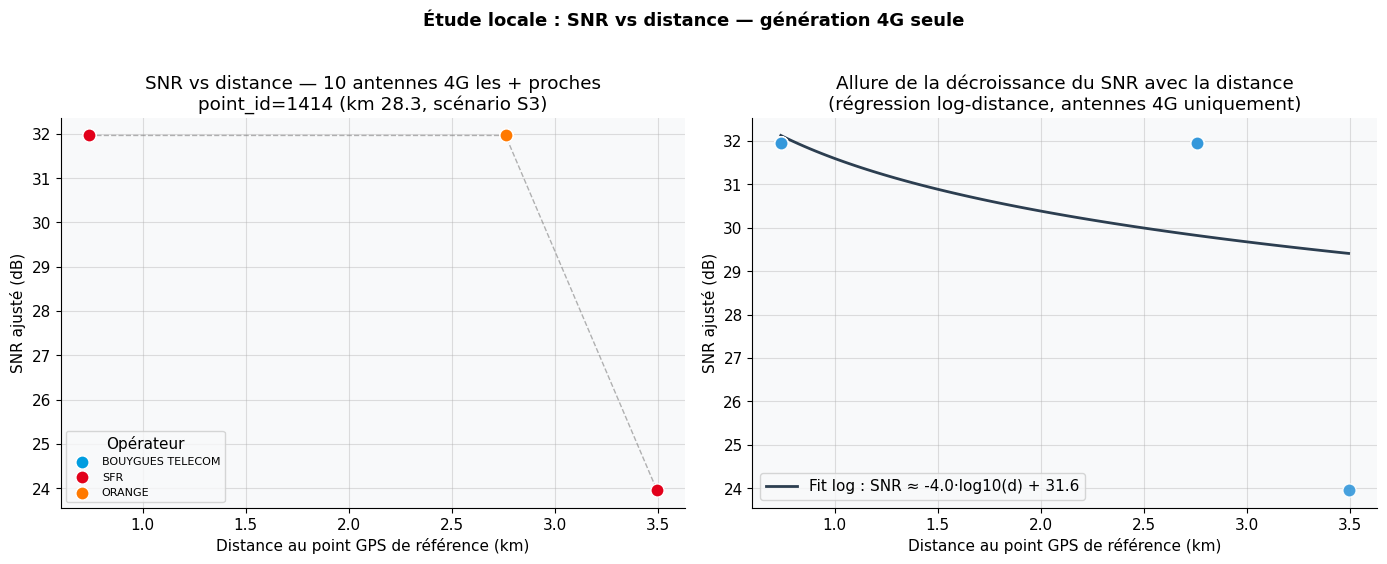

In [38]:
# ── Courbe SNR = f(distance) — antennes toutes de la même génération ──────────
top10_plot = top10[top10['snr_adjusted_db'] > -99].copy()  # exclut tunnel / pas de signal

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panneau 1 : SNR vs distance, colorié par opérateur ---
ax = axes[0]
for op in top10_plot['operateur'].unique():
    sub = top10_plot[top10_plot['operateur'] == op]
    ax.scatter(sub['dist_haversine_km'], sub['snr_adjusted_db'],
               c=PALETTE_OP.get(op, '#888888'), s=90, label=op, zorder=3,
               edgecolor='white', linewidth=1)

ax.plot(top10_plot['dist_haversine_km'], top10_plot['snr_adjusted_db'],
        color='gray', linewidth=1, linestyle='--', alpha=0.6, zorder=2)

ax.set_xlabel('Distance au point GPS de référence (km)')
ax.set_ylabel('SNR ajusté (dB)')
ax.set_title(f'SNR vs distance — 10 antennes {GEN_CIBLE} les + proches\n'
             f'point_id={POINT_ID_REF} (km {KM_REF:.1f}, scénario {SCENARIO_REF})')
ax.legend(title='Opérateur', fontsize=8)

# --- Panneau 2 : régression log-distance pour visualiser l'allure théorique ---
# Modèle attendu (path loss) : SNR ≈ a · log10(distance) + b, avec a < 0
ax2 = axes[1]
ax2.scatter(top10_plot['dist_haversine_km'], top10_plot['snr_adjusted_db'],
            c=PALETTE_GEN[GEN_CIBLE], s=90, alpha=0.9, edgecolor='white', linewidth=1, zorder=3)

x = top10_plot['dist_haversine_km'].values
y = top10_plot['snr_adjusted_db'].values

if len(x) >= 3:
    coeffs = np.polyfit(np.log10(x), y, 1)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = coeffs[0] * np.log10(x_fit) + coeffs[1]
    ax2.plot(x_fit, y_fit, color='#2c3e50', linewidth=2,
              label=f'Fit log : SNR ≈ {coeffs[0]:.1f}·log10(d) + {coeffs[1]:.1f}')
    ax2.legend()

    r2 = np.corrcoef(coeffs[0] * np.log10(x) + coeffs[1], y)[0, 1]**2
    print(f"Pente du fit log-distance : {coeffs[0]:.2f} dB par décade de distance "
          f"({'décroissance cohérente avec la physique ✓' if coeffs[0] < 0 else '⚠ pente positive, vérifier les données'})")
    print(f"R² du fit : {r2:.3f}")

ax2.set_xlabel('Distance au point GPS de référence (km)')
ax2.set_ylabel('SNR ajusté (dB)')
ax2.set_title(f'Allure de la décroissance du SNR avec la distance\n(régression log-distance, antennes {GEN_CIBLE} uniquement)')

plt.suptitle(f'Étude locale : SNR vs distance — génération {GEN_CIBLE} seule',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'fig_snr_vs_distance_{GEN_CIBLE}.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print("Nb total de lignes pour ce point (toutes générations) :", len(df_sc[df_sc['point_id'] == POINT_ID_REF]))
print(df_sc[df_sc['point_id'] == POINT_ID_REF]['generation'].value_counts())
print()
print("in_tunnel pour ce point :", df_sc[df_sc['point_id'] == POINT_ID_REF]['in_tunnel'].unique())
print()
print("Nb lignes après filtre génération avant dropna ant_id :", len(df_point))
print(df_point[['ant_id','generation','snr_adjusted_db']] if len(df_point) else "df_point est VIDE")

Nb total de lignes pour ce point (toutes générations) : 15
generation
4G    7
3G    4
2G    3
5G    1
Name: count, dtype: int64

in_tunnel pour ce point : [ True]

Nb lignes après filtre génération avant dropna ant_id : 7
       ant_id generation  snr_adjusted_db
14422  500671         4G            -99.0
14423  691395         4G            -99.0
14424  500672         4G            -99.0
14425  308884         4G            -99.0
14426  500670         4G            -99.0
14427  308880         4G            -99.0
14428  308881         4G            -99.0


In [39]:
# ── Paramètres à ajuster ────────────────────────────────────────────────────────
GEN_CIBLE = '4G'   # <-- change ici : '2G', '3G', '4G' ou '5G'

# On fixe un seul scénario météo pour ne pas dupliquer le même point_id (S1 à S4 concaténés)
SCENARIO_REF = 'S1' if 'S1' in df['scenario_id'].unique() else sorted(df['scenario_id'].unique())[0]
df_sc = df[df['scenario_id'] == SCENARIO_REF].copy()

# ── Population complète : TOUTES les paires (point, antenne) de la génération ciblée ──
# On exclut les tunnels (pas de signal) et la sentinelle snr_adjusted_db == -99
df_gen = df_sc[(df_sc['generation'] == GEN_CIBLE) &
               (~df_sc['in_tunnel']) &
               (df_sc['snr_adjusted_db'] > -99)].copy()

print(f"Génération étudiée : {GEN_CIBLE} | scénario météo : {SCENARIO_REF}")
print(f"Nombre de paires (point, antenne) valides : {len(df_gen)}")
print(f"Nombre de points GPS distincts couverts   : {df_gen['point_id'].nunique()}")
print(f"Nombre d'antennes {GEN_CIBLE} distinctes impliquées : {df_gen['ant_id'].nunique()}")
print()
print(df_gen['dist_ant_km'].describe().round(2).to_string())

Génération étudiée : 4G | scénario météo : S3
Nombre de paires (point, antenne) valides : 15282
Nombre de points GPS distincts couverts   : 1752
Nombre d'antennes 4G distinctes impliquées : 122

count    15282.00
mean         1.70
std          0.97
min          0.01
25%          0.94
50%          1.58
75%          2.28
max          4.39


Pente du fit log-distance : 3.00 dB par décade de distance (⚠ pente positive, vérifier les données)
R² du fit (sur 15282 paires) : 0.174


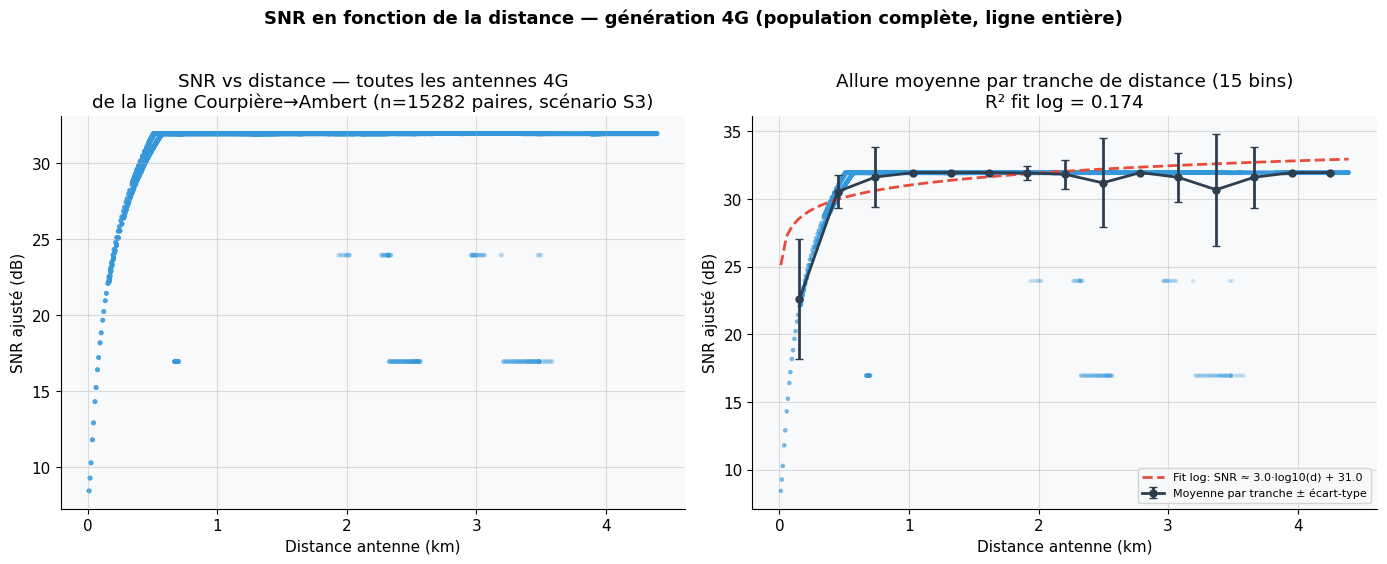

In [40]:
# ── SNR = f(distance) sur toute la population 4G de la ligne ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panneau 1 : nuage de points brut ---
ax = axes[0]
ax.scatter(df_gen['dist_ant_km'], df_gen['snr_adjusted_db'],
           c=PALETTE_GEN[GEN_CIBLE], s=12, alpha=0.35, edgecolor='none')
ax.set_xlabel('Distance antenne (km)')
ax.set_ylabel('SNR ajusté (dB)')
ax.set_title(f'SNR vs distance — toutes les antennes {GEN_CIBLE}\n'
             f'de la ligne Courpière→Ambert (n={len(df_gen)} paires, scénario {SCENARIO_REF})')

# --- Panneau 2 : moyenne par tranche de distance + fit log ---
ax2 = axes[1]
ax2.scatter(df_gen['dist_ant_km'], df_gen['snr_adjusted_db'],
            c=PALETTE_GEN[GEN_CIBLE], s=10, alpha=0.2, edgecolor='none', zorder=2)

df_gen['dist_bin'] = pd.cut(df_gen['dist_ant_km'], bins=15)
binned = df_gen.groupby('dist_bin', observed=True)['snr_adjusted_db'].agg(['mean', 'std', 'count'])
midpoints = [interval.mid for interval in binned.index]
ax2.errorbar(midpoints, binned['mean'], yerr=binned['std'],
             color='#2c3e50', linewidth=2, marker='o', markersize=5,
             capsize=3, zorder=3, label='Moyenne par tranche ± écart-type')

# Fit log-distance sur la population complète (modèle de path loss)
x = df_gen['dist_ant_km'].values
y = df_gen['snr_adjusted_db'].values
coeffs = np.polyfit(np.log10(x), y, 1)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = coeffs[0] * np.log10(x_fit) + coeffs[1]
ax2.plot(x_fit, y_fit, color='#e74c3c', linewidth=2, linestyle='--',
          label=f'Fit log: SNR ≈ {coeffs[0]:.1f}·log10(d) + {coeffs[1]:.1f}')

r2 = np.corrcoef(coeffs[0] * np.log10(x) + coeffs[1], y)[0, 1]**2
print(f"Pente du fit log-distance : {coeffs[0]:.2f} dB par décade de distance "
      f"({'décroissance cohérente avec la physique ✓' if coeffs[0] < 0 else '⚠ pente positive, vérifier les données'})")
print(f"R² du fit (sur {len(df_gen)} paires) : {r2:.3f}")

ax2.legend(fontsize=8)
ax2.set_xlabel('Distance antenne (km)')
ax2.set_ylabel('SNR ajusté (dB)')
ax2.set_title(f'Allure moyenne par tranche de distance (15 bins)\nR² fit log = {r2:.3f}')

plt.suptitle(f'SNR en fonction de la distance — génération {GEN_CIBLE} (population complète, ligne entière)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'fig_snr_vs_distance_{GEN_CIBLE}_global.png', dpi=150, bbox_inches='tight')
plt.show()

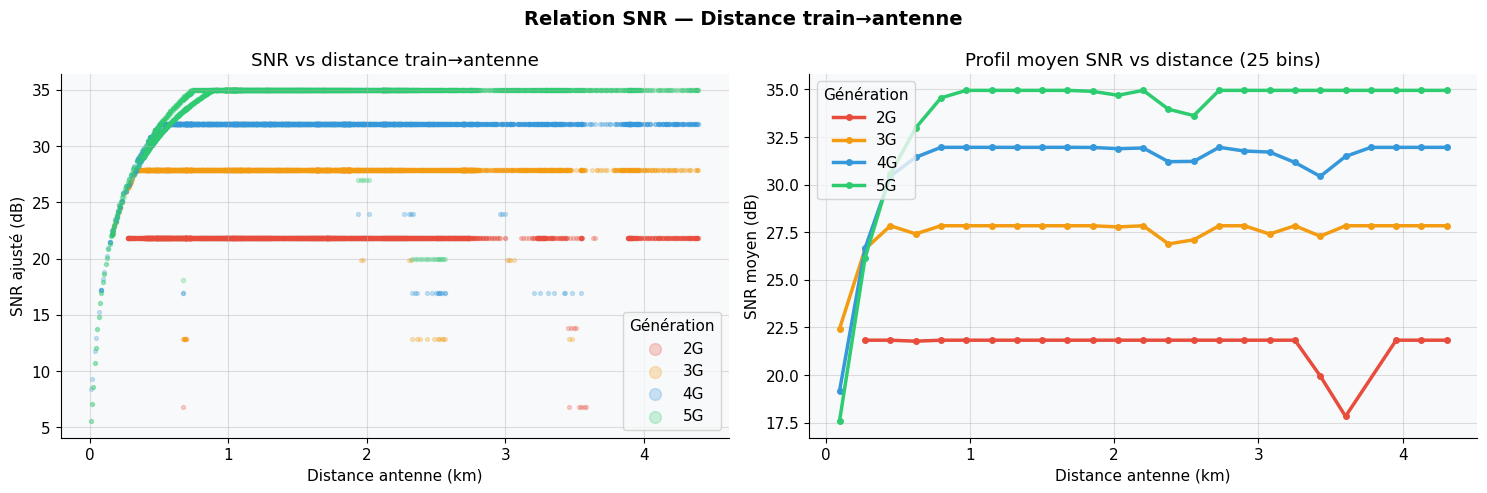

In [45]:
# Scatter SNR vs distance par génération (hors tunnel, filtre sentinelle -99)
df_snr = df_cell[
    (~df_cell['in_tunnel']) &
    (df_cell['snr_adjusted_db'] > -99)
].copy()

df_snr['dist_bin'] = pd.cut(df_snr['dist_ant_km'], bins=25)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter
for gen in gen_order:
    sub = df_snr[df_snr['generation'] == gen].sample(min(3000, len(df_snr[df_snr['generation']==gen])), random_state=42)
    axes[0].scatter(sub['dist_ant_km'], sub['snr_adjusted_db'],
                    c=PALETTE_GEN[gen], alpha=0.25, s=8, label=gen)
axes[0].set_xlabel('Distance antenne (km)')
axes[0].set_ylabel('SNR ajusté (dB)')
axes[0].set_title('SNR vs distance train→antenne')
axes[0].legend(title='Génération', markerscale=3)

# Profil moyen par bin
for gen in gen_order:
    sub = df_snr[df_snr['generation'] == gen]
    mean_snr = sub.groupby('dist_bin', observed=True)['snr_adjusted_db'].mean()
    midpoints = [i.mid for i in mean_snr.index]
    axes[1].plot(midpoints, mean_snr.values, color=PALETTE_GEN[gen],
                 linewidth=2.5, label=gen, marker='o', markersize=4)
axes[1].set_xlabel('Distance antenne (km)')
axes[1].set_ylabel('SNR moyen (dB)')
axes[1].set_title('Profil moyen SNR vs distance (25 bins)')
axes[1].legend(title='Génération')

plt.suptitle('Relation SNR — Distance train→antenne', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_snr_distance.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ── Sélection d'un point GPS dont les antennes candidates couvrent un large étalement de distance ──
# Objectif : avoir un vrai étalement (ex: jusqu'à 15-20 km) pour observer la décroissance SNR
# sur une plage de distance large, plutôt que d'être limité par un point en zone peu étalée.

resultats_etalement = []
for _, p in pts_ligne_ht.iterrows():
    cand = df_sc[(df_sc['point_id'] == p['point_id']) &
                 (df_sc['generation'] == GEN_CIBLE)].drop_duplicates('ant_id')
    if len(cand) < N_ANTENNES:
        continue
    d = haversine_km(p['lat'], p['lon'], cand['ant_lat'], cand['ant_lon'])
    resultats_etalement.append({
        'point_id': p['point_id'],
        'distance_km_ligne': p['distance_km'],
        'nb_ant': len(cand),
        'd_min': d.min(),
        'd_max': d.max(),
        'etalement_km': d.max() - d.min()
    })

etal_df = pd.DataFrame(resultats_etalement).sort_values('etalement_km', ascending=False)
print("Top 5 points avec le plus grand étalement de distance parmi leurs antennes 4G candidates :")
print(etal_df.head(5).round(2).to_string(index=False))

# On prend le point avec le plus grand étalement
point_etale = etal_df.iloc[0]
POINT_ID_REF2 = point_etale['point_id']
ref_row = pts_ligne_ht[pts_ligne_ht['point_id'] == POINT_ID_REF2].iloc[0]
LAT_REF2, LON_REF2, KM_REF2 = ref_row['lat'], ref_row['lon'], ref_row['distance_km']

print(f"\nPoint retenu : point_id={POINT_ID_REF2} | km {KM_REF2:.2f} | "
      f"étalement = {point_etale['etalement_km']:.1f} km "
      f"(de {point_etale['d_min']:.1f} à {point_etale['d_max']:.1f} km)")

# Recalcul du top 10 pour ce nouveau point
df_point2 = df_sc[(df_sc['point_id'] == POINT_ID_REF2) &
                   (df_sc['generation'] == GEN_CIBLE)].drop_duplicates('ant_id').copy()
df_point2['dist_haversine_km'] = haversine_km(LAT_REF2, LON_REF2,
                                                 df_point2['ant_lat'], df_point2['ant_lon'])
top10_etale = df_point2.sort_values('dist_haversine_km').head(N_ANTENNES).reset_index(drop=True)

cols_show = ['ant_id', 'operateur', 'bande_mhz', 'dist_haversine_km', 'snr_adjusted_db']
print(f"\n{len(top10_etale)} antennes {GEN_CIBLE} pour ce point (étalement large) :")
print(top10_etale[cols_show].round(3).to_string(index=False))

Top 5 points avec le plus grand étalement de distance parmi leurs antennes 4G candidates :
 point_id  distance_km_ligne  nb_ant  d_min  d_max  etalement_km
     1492              29.84      11   0.38   3.43          3.05
     1493              29.86      11   0.39   3.45          3.05
     1491              29.82      11   0.37   3.42          3.05
     1490              29.80      11   0.36   3.41          3.05
     1489              29.78      11   0.35   3.40          3.05

Point retenu : point_id=1492.0 | km 29.84 | étalement = 3.1 km (de 0.4 à 3.4 km)

10 antennes 4G pour ce point (étalement large) :
 ant_id        operateur  bande_mhz  dist_haversine_km  snr_adjusted_db
 195670 BOUYGUES TELECOM        800              0.380            29.55
 803135              SFR        800              0.380            29.55
 195668 BOUYGUES TELECOM       1800              0.380            29.55
 803133              SFR       1800              0.380            29.55
 803134              SFR   

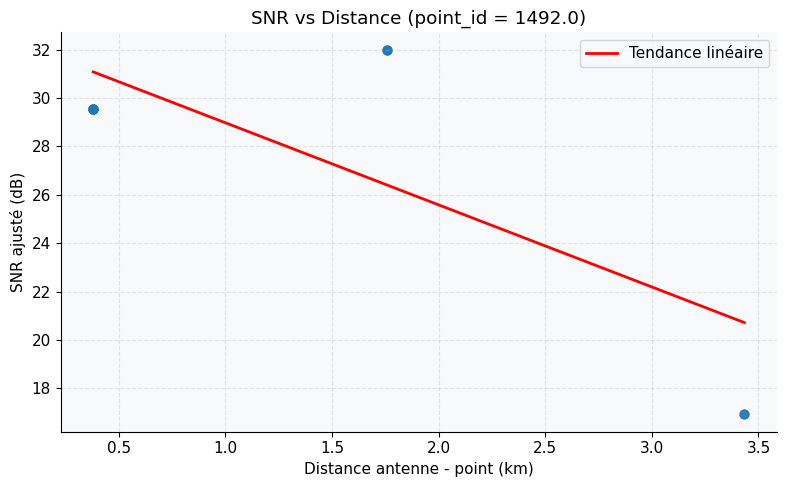

In [44]:
# ── Données pour le point sélectionné ─────────────────────────────────────────
df_plot = df_sc[(df_sc['point_id'] == POINT_ID_REF2) &
                (df_sc['generation'] == GEN_CIBLE)].drop_duplicates('ant_id').copy()

# Distance haversine
df_plot['dist_km'] = haversine_km(
    LAT_REF2, LON_REF2,
    df_plot['ant_lat'], df_plot['ant_lon']
)

# ── Nettoyage (optionnel mais recommandé) ─────────────────────────────────────
df_plot = df_plot.dropna(subset=['snr_adjusted_db', 'dist_km'])

# ── Plot SNR vs distance ──────────────────────────────────────────────────────
plt.figure(figsize=(8,5))

plt.scatter(df_plot['dist_km'],
            df_plot['snr_adjusted_db'],
            alpha=0.7, s=40, color='#1f77b4')

# tendance (optionnel)
z = np.polyfit(df_plot['dist_km'], df_plot['snr_adjusted_db'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_plot['dist_km'].min(), df_plot['dist_km'].max(), 100)

plt.plot(x_line, p(x_line), color='red', lw=2, label='Tendance linéaire')

# ── Styling ───────────────────────────────────────────────────────────────────
plt.title(f"SNR vs Distance (point_id = {POINT_ID_REF2})")
plt.xlabel("Distance antenne - point (km)")
plt.ylabel("SNR ajusté (dB)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()